# Eksperimen 1: Refinement Model Deteksi Flaky Test dengan Leave-One-Project-Out Cross-Validation (LOOCV)
**Dataset**: FlakeFlagger Benchmark (24 Proyek GitHub, 22.234 Test Cases, 23 Fitur)  
**Evaluasi**: Leave-One-Project-Out Cross-Validation (LOOCV / LOPO-CV)  
**Fokus Refinement**:
1. **Pre-Data Processing & Zero-Leakage Pipeline**: Median Imputation dan StandardScaler/RobustScaler yang di-fit strictly hanya pada 23 proyek training setiap fold.
2. **Penyetaraan Dataset (Equalization)**:
   - Penyetaraan kelas (Cost-sensitive weighting `class_weight='balanced'`, `scale_pos_weight`, SMOTE oversampling, Random Under-Sampling / RUS, dan Balanced Random Forest).
   - Penyetaraan kontribusi proyek (Project-weighted loss agar proyek raksasa seperti `assertj-core` tidak menenggelamkan proyek kecil seperti `commons-exec`).
3. **Optimasi Ambang Batas (Dynamic Inner-CV Threshold Tuning)**: Menemukan ambang batas optimal $\tau^*$ via Inner GroupKFold pada data latih tanpa kebocoran data (*zero test-set leakage*).
4. **Komparasi 16 Model Klasifikasi & 5 Model Regresi**:
   - Random Forest (Baseline, Balanced, SMOTE, RUS, Balanced-RF)
   - Extra Trees (Balanced)
   - XGBoost (Baseline, ClassWeight, RUS)
   - LightGBM (Baseline, Balanced, SMOTE)
   - Gradient Boosting (Balanced)
   - Logistic Regression (Balanced)
   - Multi-Layer Perceptron / Neural Network (Balanced)
   - Refined Soft-Voting Ensemble
   - Regresi Keparahan Flaky (`NumFailingRuns`): RF, Extra Trees, Gradient Boosting, LightGBM, Ridge
5. **Uji Signifikansi Statistik**: Uji Chi-Square Friedman & pemeringkatan Nemenyi.

## 1. Setup Environment & Import Libraries

In [1]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown, Image

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 150

RESULTS_DIR = Path("results")
print(f"Results Directory exists: {RESULTS_DIR.exists()}")


Results Directory exists: True


## 2. Eksplorasi Dataset FlakeFlagger & Analisis Ketimpangan Antar-Proyek
Dataset FlakeFlagger terdiri dari **24 proyek Java Open-Source**.  
Ketimpangan terjadi pada dua dimensi krusial:
1. **Dimensi Kelas**: Rasio flaky rata-rata hanya 3.65% (811 flaky vs 21.423 non-flaky).
2. **Dimensi Proyek**: Ukuran proyek berkisar dari 55 test case (`commons-exec`) hingga 6.261 test case (`assertj-core`). Persentase flaky bervariasi dari 0.00% (`jimfs`) hingga 62.03% (`alluxio`).

In [2]:
# Muat ringkasan detail per proyek dari hasil LOOCV
df_detailed = pd.read_csv(RESULTS_DIR / "classification_loocv_detailed.csv")

# Tampilkan ringkasan distribusi test cases dan flaky test per proyek
proj_dist = df_detailed[df_detailed["Algorithm"] == "RF_Baseline"][["Project_ID", "Project", "Test_Samples", "Flaky_Samples"]].drop_duplicates()
proj_dist["Non_Flaky"] = proj_dist["Test_Samples"] - proj_dist["Flaky_Samples"]
proj_dist["Flaky_Pct (%)"] = (proj_dist["Flaky_Samples"] / proj_dist["Test_Samples"] * 100).round(2)
proj_dist = proj_dist.sort_values(by="Test_Samples", ascending=False).reset_index(drop=True)

display(proj_dist)
print(f"Total Test Cases: {proj_dist['Test_Samples'].sum()}")
print(f"Total Flaky Tests: {proj_dist['Flaky_Samples'].sum()} ({proj_dist['Flaky_Samples'].sum()/proj_dist['Test_Samples'].sum()*100:.2f}%)")


,Project_ID,Project,Test_Samples,Flaky_Samples,Non_Flaky,Flaky_Pct (%)
0,E12,assertj-core,6261,1,6260,0.02
1,E06,incubator-dubbo,2176,19,2157,0.87
2,E17,spring-boot,2127,163,1964,7.66
3,E00,activiti,2044,32,2012,1.57
4,E07,achilles,1317,4,1313,0.30
5,E21,wildfly,1236,23,1213,1.86
6,E22,wro4j,1145,16,1129,1.40
7,E16,logback,842,22,820,2.61
8,E18,okhttp,810,100,710,12.35
9,E05,httpcore,712,22,690,3.09


Total Test Cases: 22234
Total Flaky Tests: 811 (3.65%)


## 3. Strategi Pre-Data Processing & Penyetaraan Dataset

Dalam Cross-Project LOOCV, model dilatih pada 23 proyek dan diuji pada 1 proyek yang sama sekali belum pernah dilihat.
Untuk mengatasi *cross-project distribution shift* dan *extreme class imbalance*, kami menerapkan strategi refinement terpadu:

1. **Zero-Leakage Preprocessing**:
   - `SimpleImputer(strategy='median')`: Mengisi nilai hilang pada fitur kode (`testLength`, `numAsserts`, `numCoveredLines`) hanya berdasarkan statistik training fold.
   - `StandardScaler()`: Menstandarisasi fitur prediktor secara independen pada setiap fold.
2. **Penyetaraan Proporsi Kelas**:
   - **Cost-Sensitive Weighting**: Menetapkan bobot rugi $w_1 = 
rac{N_{neg}}{N_{pos}}$ pada loss function (`RF_Balanced`, `XGB_ClassWeight`, `LightGBM_Balanced`, `GB_Balanced`).
   - **SMOTE (Synthetic Minority Over-sampling)**: Mensintesis sampel flaky baru di ruang fitur lokal ($k=3$).
   - **Random Under-Sampling (RUS)**: Menyeimbangkan rasio kelas mayoritas menjadi proporsional (1:3).
   - **Balanced Random Forest**: Melakukan bootstraping berimbang di setiap decision tree.
3. **Penyetaraan Kontribusi Proyek (Project-Weighting)**:
   - Bobot sampel dihitung berbanding terbalik dengan ukuran proyek ($w_i \propto 1 / N_{proj}$) agar `assertj-core` (6.261 sampel) tidak memonopoli pemisahan fitur dibandingkan `commons-exec` (55 sampel).
4. **Optimasi Ambang Batas (Dynamic Inner-CV Threshold Tuning)**:
   - Alih-alih memakai ambang default 0.50 (yang menyebabkan model memprediksi 0 flaky test pada proyek berimbalance tinggi), kami menggunakan Inner GroupKFold (3-split) pada 23 proyek training untuk menemukan threshold optimal $\tau^*$ yang memaksimalkan F1-Score.

## 4. Hasil Komparasi Refinement Model Klasifikasi (LOOCV)

In [3]:
# Muat ringkasan metrik klasifikasi
df_summary = pd.read_csv(RESULTS_DIR / "classification_loocv_summary.csv")

# Pisahkan perbandingan threshold Default (0.50) vs Tuned (Inner-CV)
df_tuned = df_summary[df_summary["Threshold_Type"] == "Tuned_InnerCV"].copy()
df_tuned = df_tuned.sort_values(by="F1_Mean", ascending=False).reset_index(drop=True)

display(Markdown("### Tabel Performa Model Klasifikasi dengan Dynamic Threshold Tuning (LOOCV)"))
display(df_tuned[[
    "Algorithm", 
    "F1 (Mean ± Std)", "F1_Median",
    "MCC (Mean ± Std)", "MCC_Median",
    "AUC-PR (Mean ± Std)", "ROC-AUC (Mean ± Std)",
    "Precision_Mean", "Recall_Mean", "Balanced_Acc_Mean"
]])


### Tabel Performa Model Klasifikasi dengan Dynamic Threshold Tuning (LOOCV)

,Algorithm,F1 (Mean ± Std),F1_Median,MCC (Mean ± Std),MCC_Median,AUC-PR (Mean ± Std),ROC-AUC (Mean ± Std),Precision_Mean,Recall_Mean,Balanced_Acc_Mean
0,GradientBoosting_Balanced,0.1736 ± 0.2070,0.088254,0.1433 ± 0.1826,0.057085,0.2312 ± 0.2652,0.7369 ± 0.1916,0.165482,0.409983,0.612944
1,Balanced_RF,0.1649 ± 0.2563,0.030219,0.1360 ± 0.2478,0.003288,0.2386 ± 0.2955,0.7263 ± 0.1799,0.156612,0.306592,0.580443
2,RF_RUS,0.1606 ± 0.2125,0.065591,0.1400 ± 0.1974,0.046611,0.2072 ± 0.2508,0.7197 ± 0.1915,0.181546,0.342374,0.606946
3,RF_Baseline,0.1491 ± 0.2300,0.050115,0.1305 ± 0.2267,0.029952,0.1955 ± 0.2530,0.6865 ± 0.2171,0.166556,0.321183,0.600382
4,XGB_RUS,0.1474 ± 0.1942,0.071859,0.1145 ± 0.1688,0.047966,0.2180 ± 0.2843,0.7006 ± 0.1863,0.149564,0.382675,0.596419
5,ExtraTrees_Balanced,0.1443 ± 0.2440,0.035669,0.1217 ± 0.2262,0.028323,0.2135 ± 0.2790,0.7072 ± 0.2024,0.141122,0.294844,0.582102
6,RF_Balanced,0.1405 ± 0.2298,0.030045,0.1203 ± 0.2221,0.000000,0.1990 ± 0.2527,0.7148 ± 0.2085,0.130828,0.279379,0.583217
7,RF_SMOTE,0.1341 ± 0.2343,0.037919,0.1256 ± 0.2362,0.016556,0.2280 ± 0.2997,0.7150 ± 0.1988,0.144518,0.307463,0.599562
8,LogisticRegression_Balanced,0.1270 ± 0.1543,0.096529,0.0978 ± 0.1370,0.047764,0.1628 ± 0.1862,0.6563 ± 0.1793,0.157180,0.318726,0.571366
9,MLP_Balanced,0.1249 ± 0.2099,0.030818,0.0971 ± 0.1860,0.000000,0.2062 ± 0.2900,0.6466 ± 0.2140,0.154812,0.212518,0.556419


## 5. Analisis Dampak Penyetaraan & Threshold Tuning (Default 0.50 vs Tuned)

In [4]:
# Bandingkan performa Default 0.50 vs Tuned Inner-CV
pivot_comp = df_summary.pivot(index="Algorithm", columns="Threshold_Type", values=["F1_Mean", "Recall_Mean", "MCC_Mean"])
pivot_comp.columns = [f"{col[0]}_{col[1]}" for col in pivot_comp.columns]
pivot_comp["F1_Gain (%)"] = ((pivot_comp["F1_Mean_Tuned_InnerCV"] - pivot_comp["F1_Mean_Default_0.50"]) / (pivot_comp["F1_Mean_Default_0.50"] + 1e-6) * 100).round(1)
pivot_comp["Recall_Gain (%)"] = ((pivot_comp["Recall_Mean_Tuned_InnerCV"] - pivot_comp["Recall_Mean_Default_0.50"]) / (pivot_comp["Recall_Mean_Default_0.50"] + 1e-6) * 100).round(1)
pivot_comp = pivot_comp.sort_values(by="F1_Mean_Tuned_InnerCV", ascending=False)

display(Markdown("### Perbandingan Metrik: Default (0.50) vs Tuned Threshold"))
display(pivot_comp)


### Perbandingan Metrik: Default (0.50) vs Tuned Threshold

,F1_Mean_Default_0.50,F1_Mean_Tuned_InnerCV,Recall_Mean_Default_0.50,Recall_Mean_Tuned_InnerCV,MCC_Mean_Default_0.50,MCC_Mean_Tuned_InnerCV,F1_Gain (%),Recall_Gain (%)
Algorithm,,,,,,,,
GradientBoosting_Balanced,0.161930,0.173553,0.452566,0.409983,0.142275,0.143316,7.2,-9.4
Balanced_RF,0.171098,0.164859,0.339967,0.306592,0.150443,0.135960,-3.6,-9.8
RF_RUS,0.137997,0.160552,0.271286,0.342374,0.125019,0.139991,16.3,26.2
RF_Baseline,0.021964,0.149061,0.037919,0.321183,0.017254,0.130524,578.6,747.0
XGB_RUS,0.123935,0.147402,0.259597,0.382675,0.104394,0.114537,18.9,47.4
ExtraTrees_Balanced,0.023856,0.144268,0.017497,0.294844,0.021933,0.121711,504.7,1585.0
RF_Balanced,0.034843,0.140457,0.036810,0.279379,0.027016,0.120251,303.1,659.0
RF_SMOTE,0.043586,0.134065,0.039816,0.307463,0.033453,0.125608,207.6,672.2
LogisticRegression_Balanced,0.131369,0.126957,0.515123,0.318726,0.077307,0.097819,-3.4,-38.1


## 6. Visualisasi Hasil Eksperimen Publikasi

### Distribusi Performa Model Lintas 24 Proyek

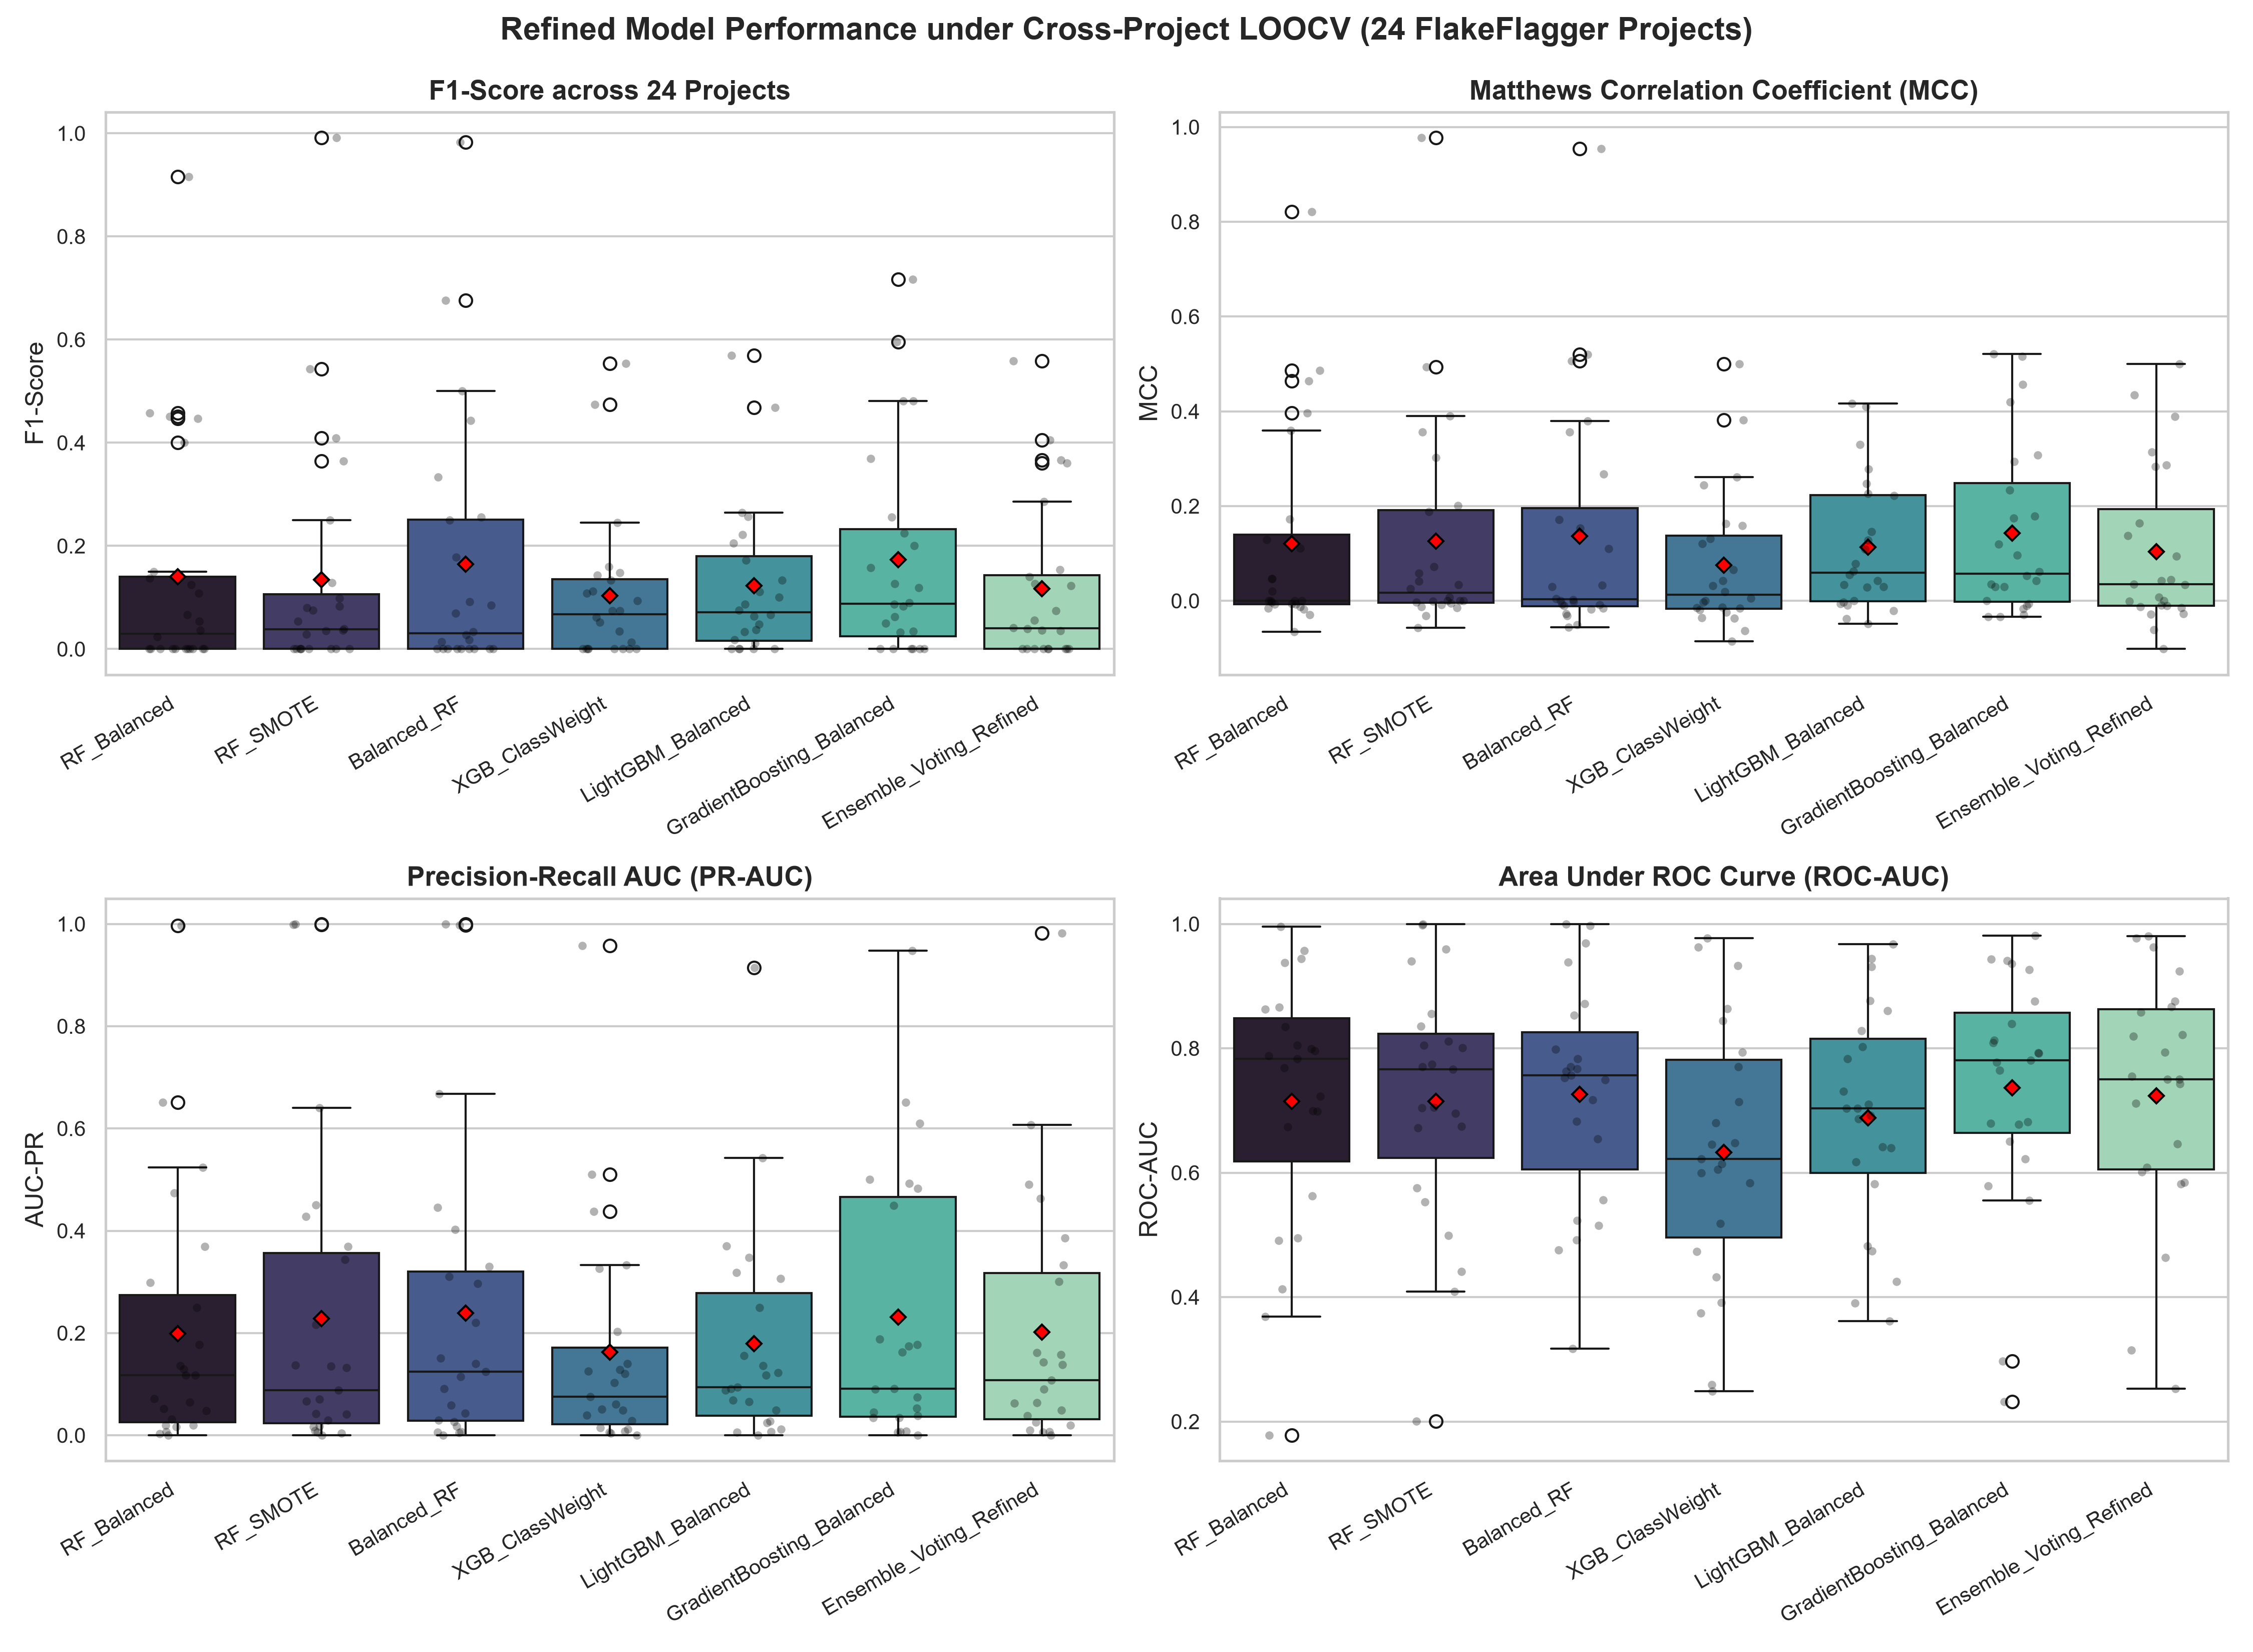

In [5]:
# 1. Boxplot & Distribusi Metrik Utama (F1, MCC, PR-AUC, ROC-AUC)
display(Markdown("### Distribusi Performa Model Lintas 24 Proyek"))
display(Image(filename=str(RESULTS_DIR / "01_classification_boxplots.png")))


### Dampak Penyetaraan Dataset & Threshold Tuning Terhadap F1-Score & Recall

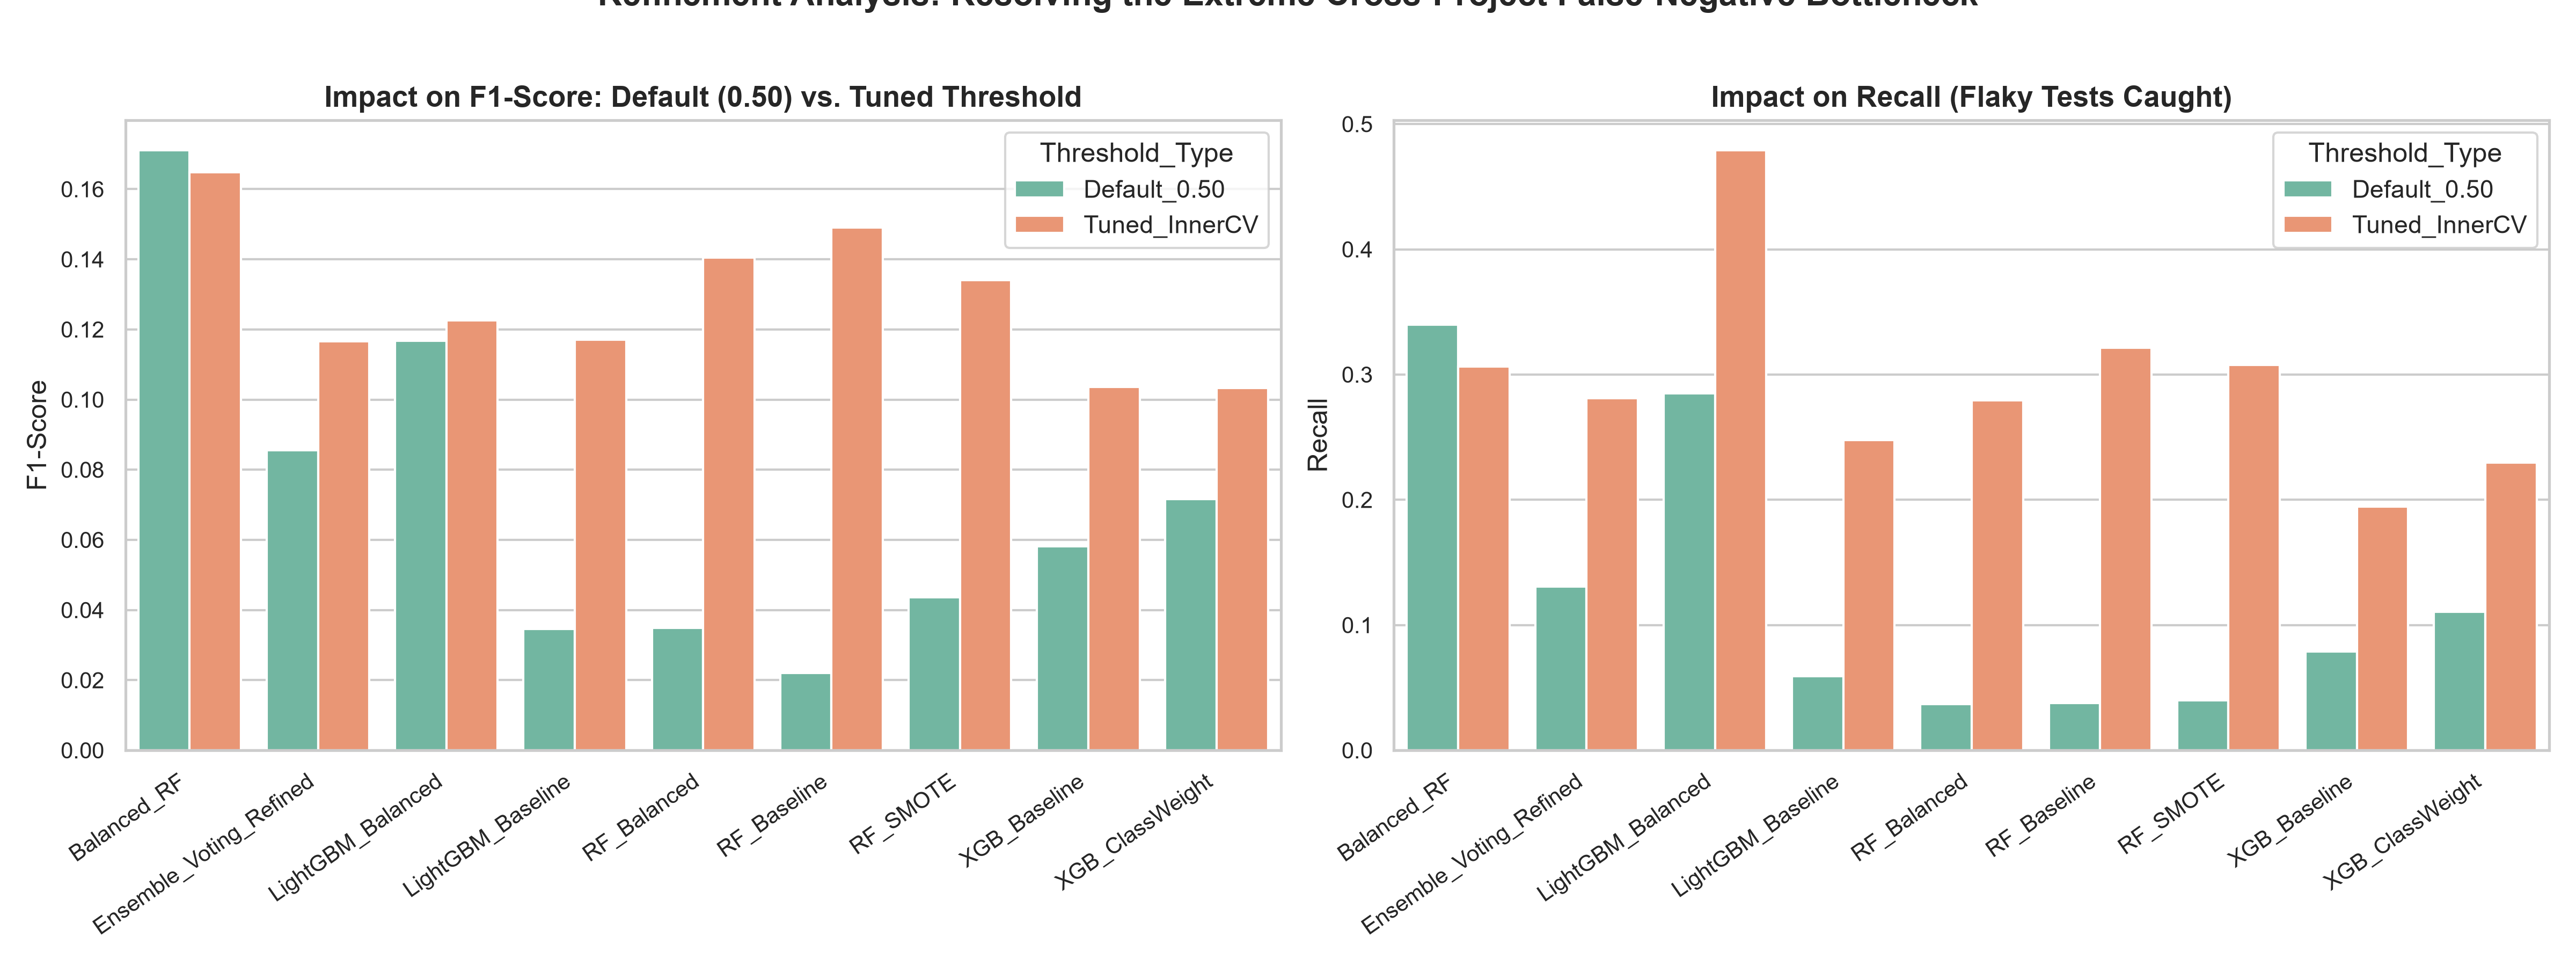

In [6]:
# 2. Dampak Penyetaraan Dataset & Threshold Tuning
display(Markdown("### Dampak Penyetaraan Dataset & Threshold Tuning Terhadap F1-Score & Recall"))
display(Image(filename=str(RESULTS_DIR / "02_threshold_impact_comparison.png")))


### Heatmap F1-Score per Proyek

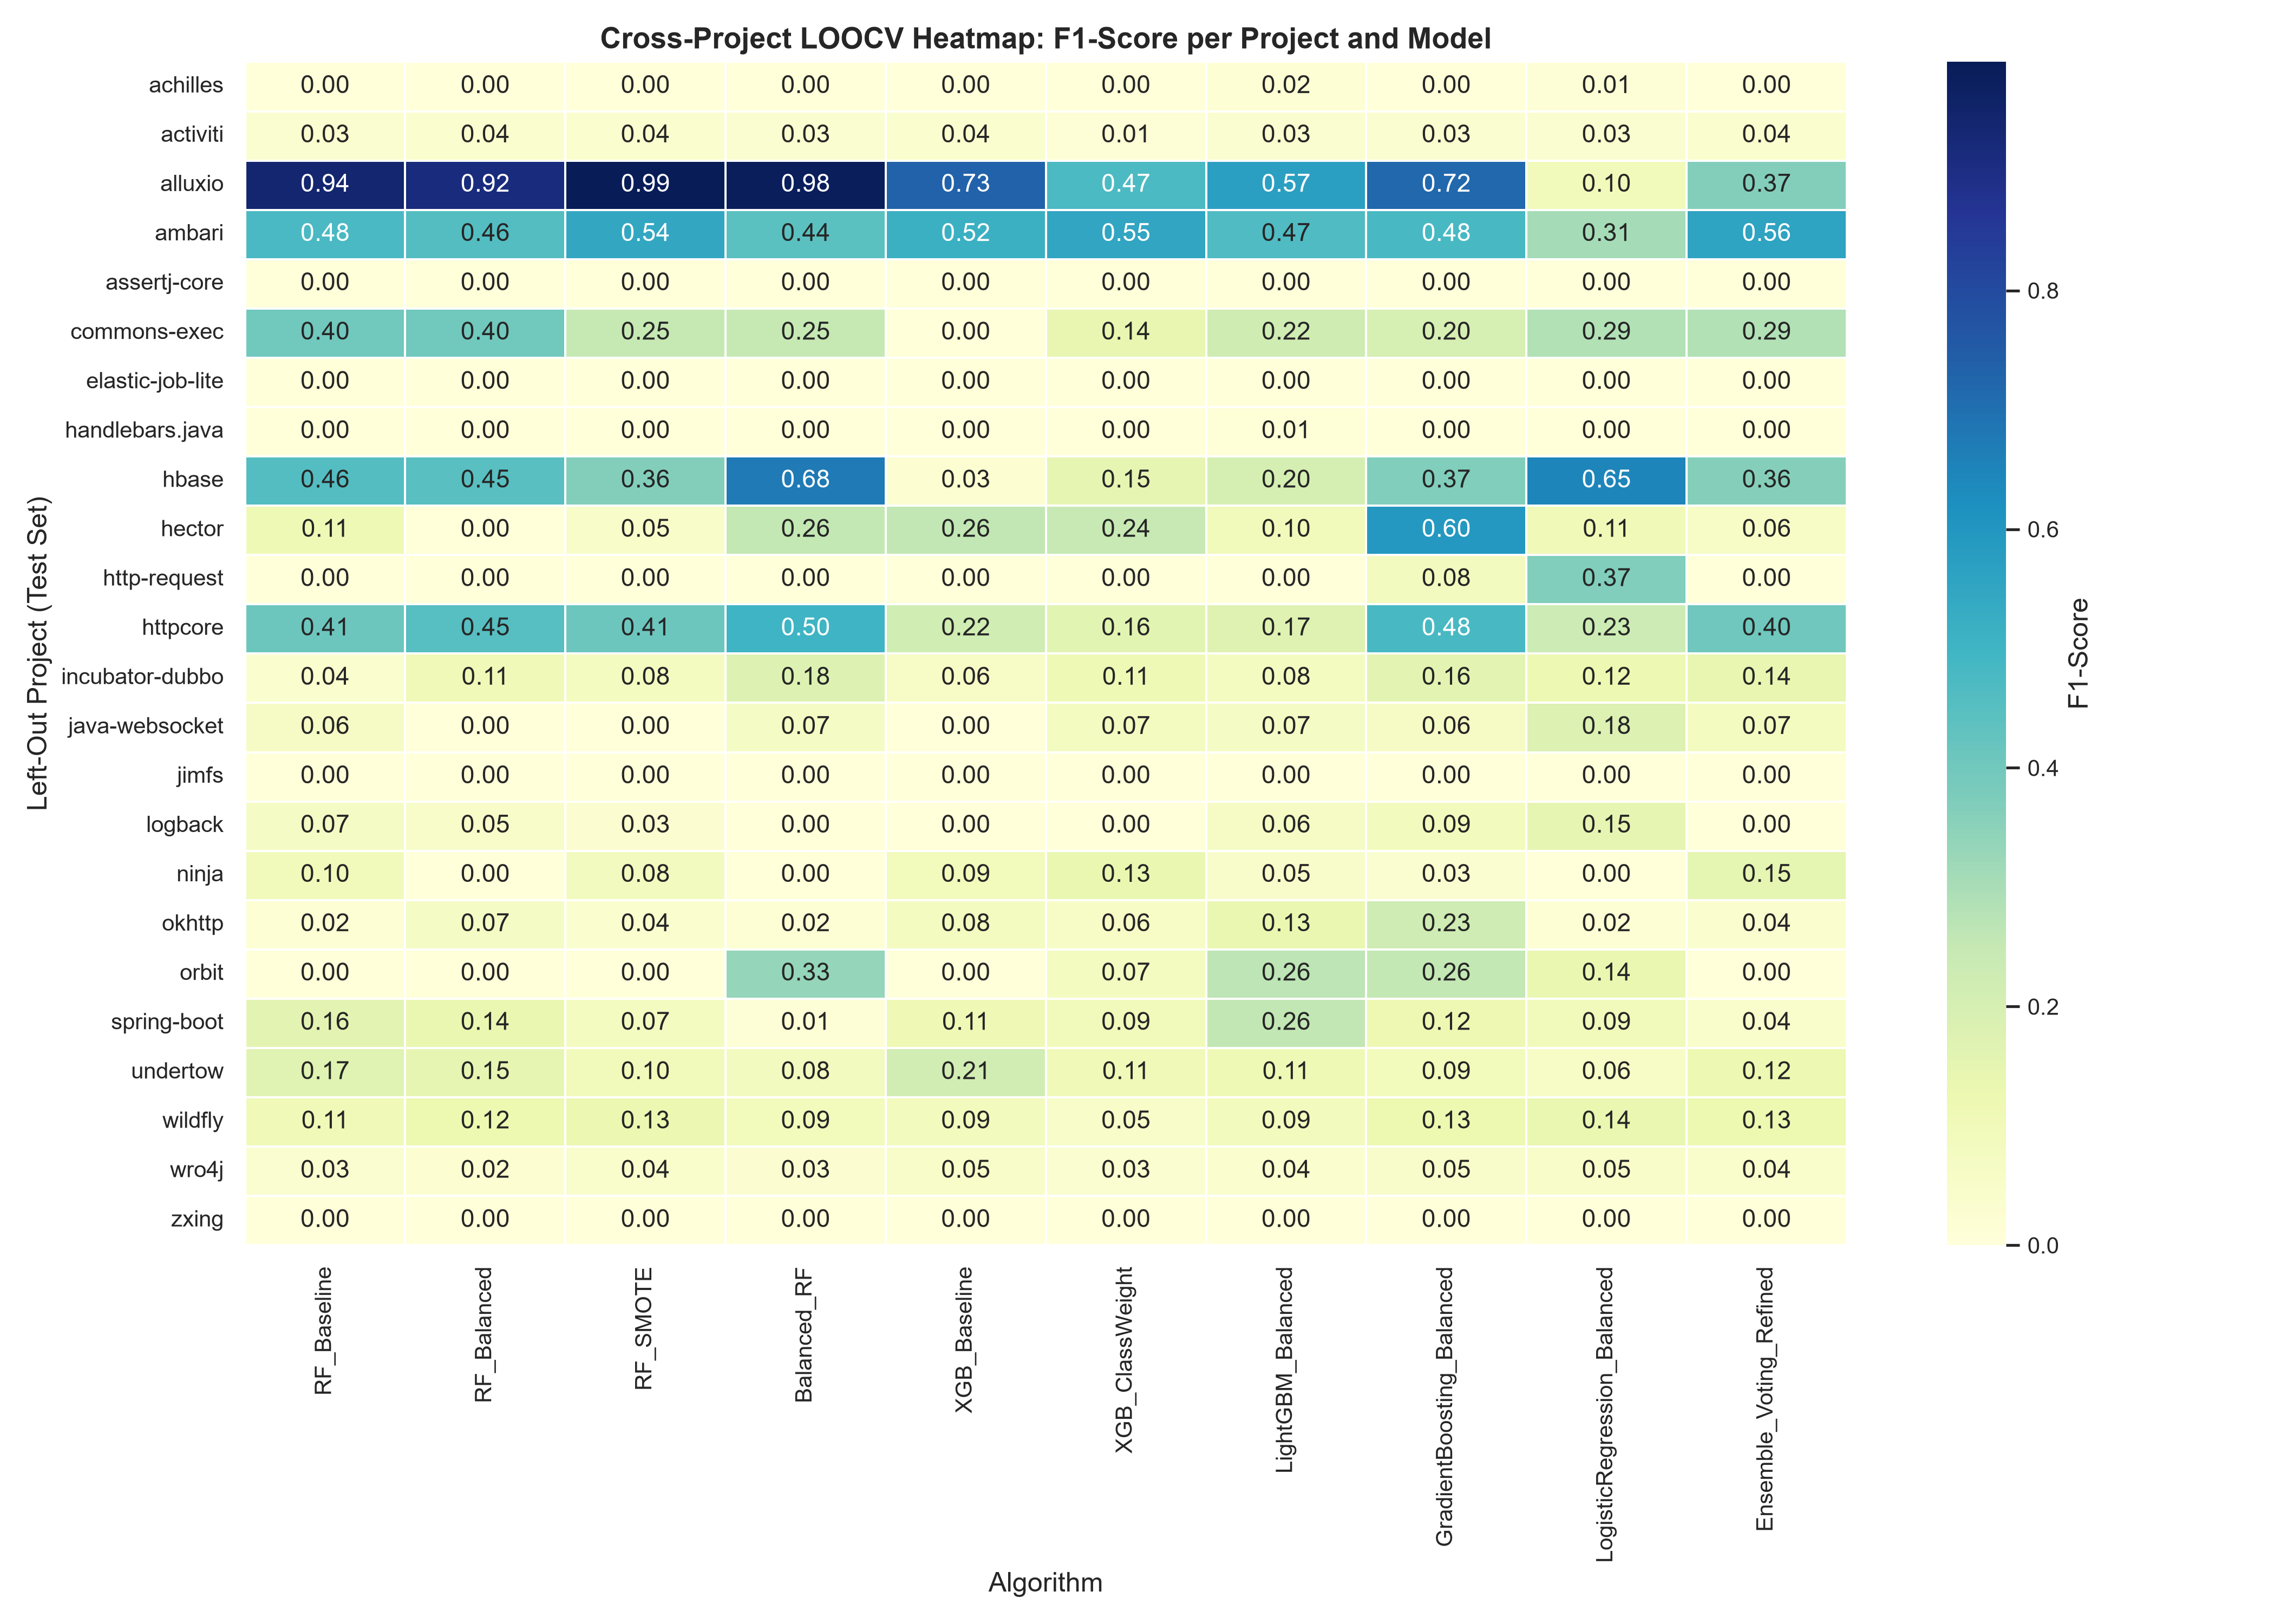

In [7]:
# 3. Heatmap F1-Score Lintas 24 Proyek
display(Markdown("### Heatmap F1-Score per Proyek"))
display(Image(filename=str(RESULTS_DIR / "03_f1_heatmap_per_project.png")))


### Heatmap Matthews Correlation Coefficient (MCC) per Proyek

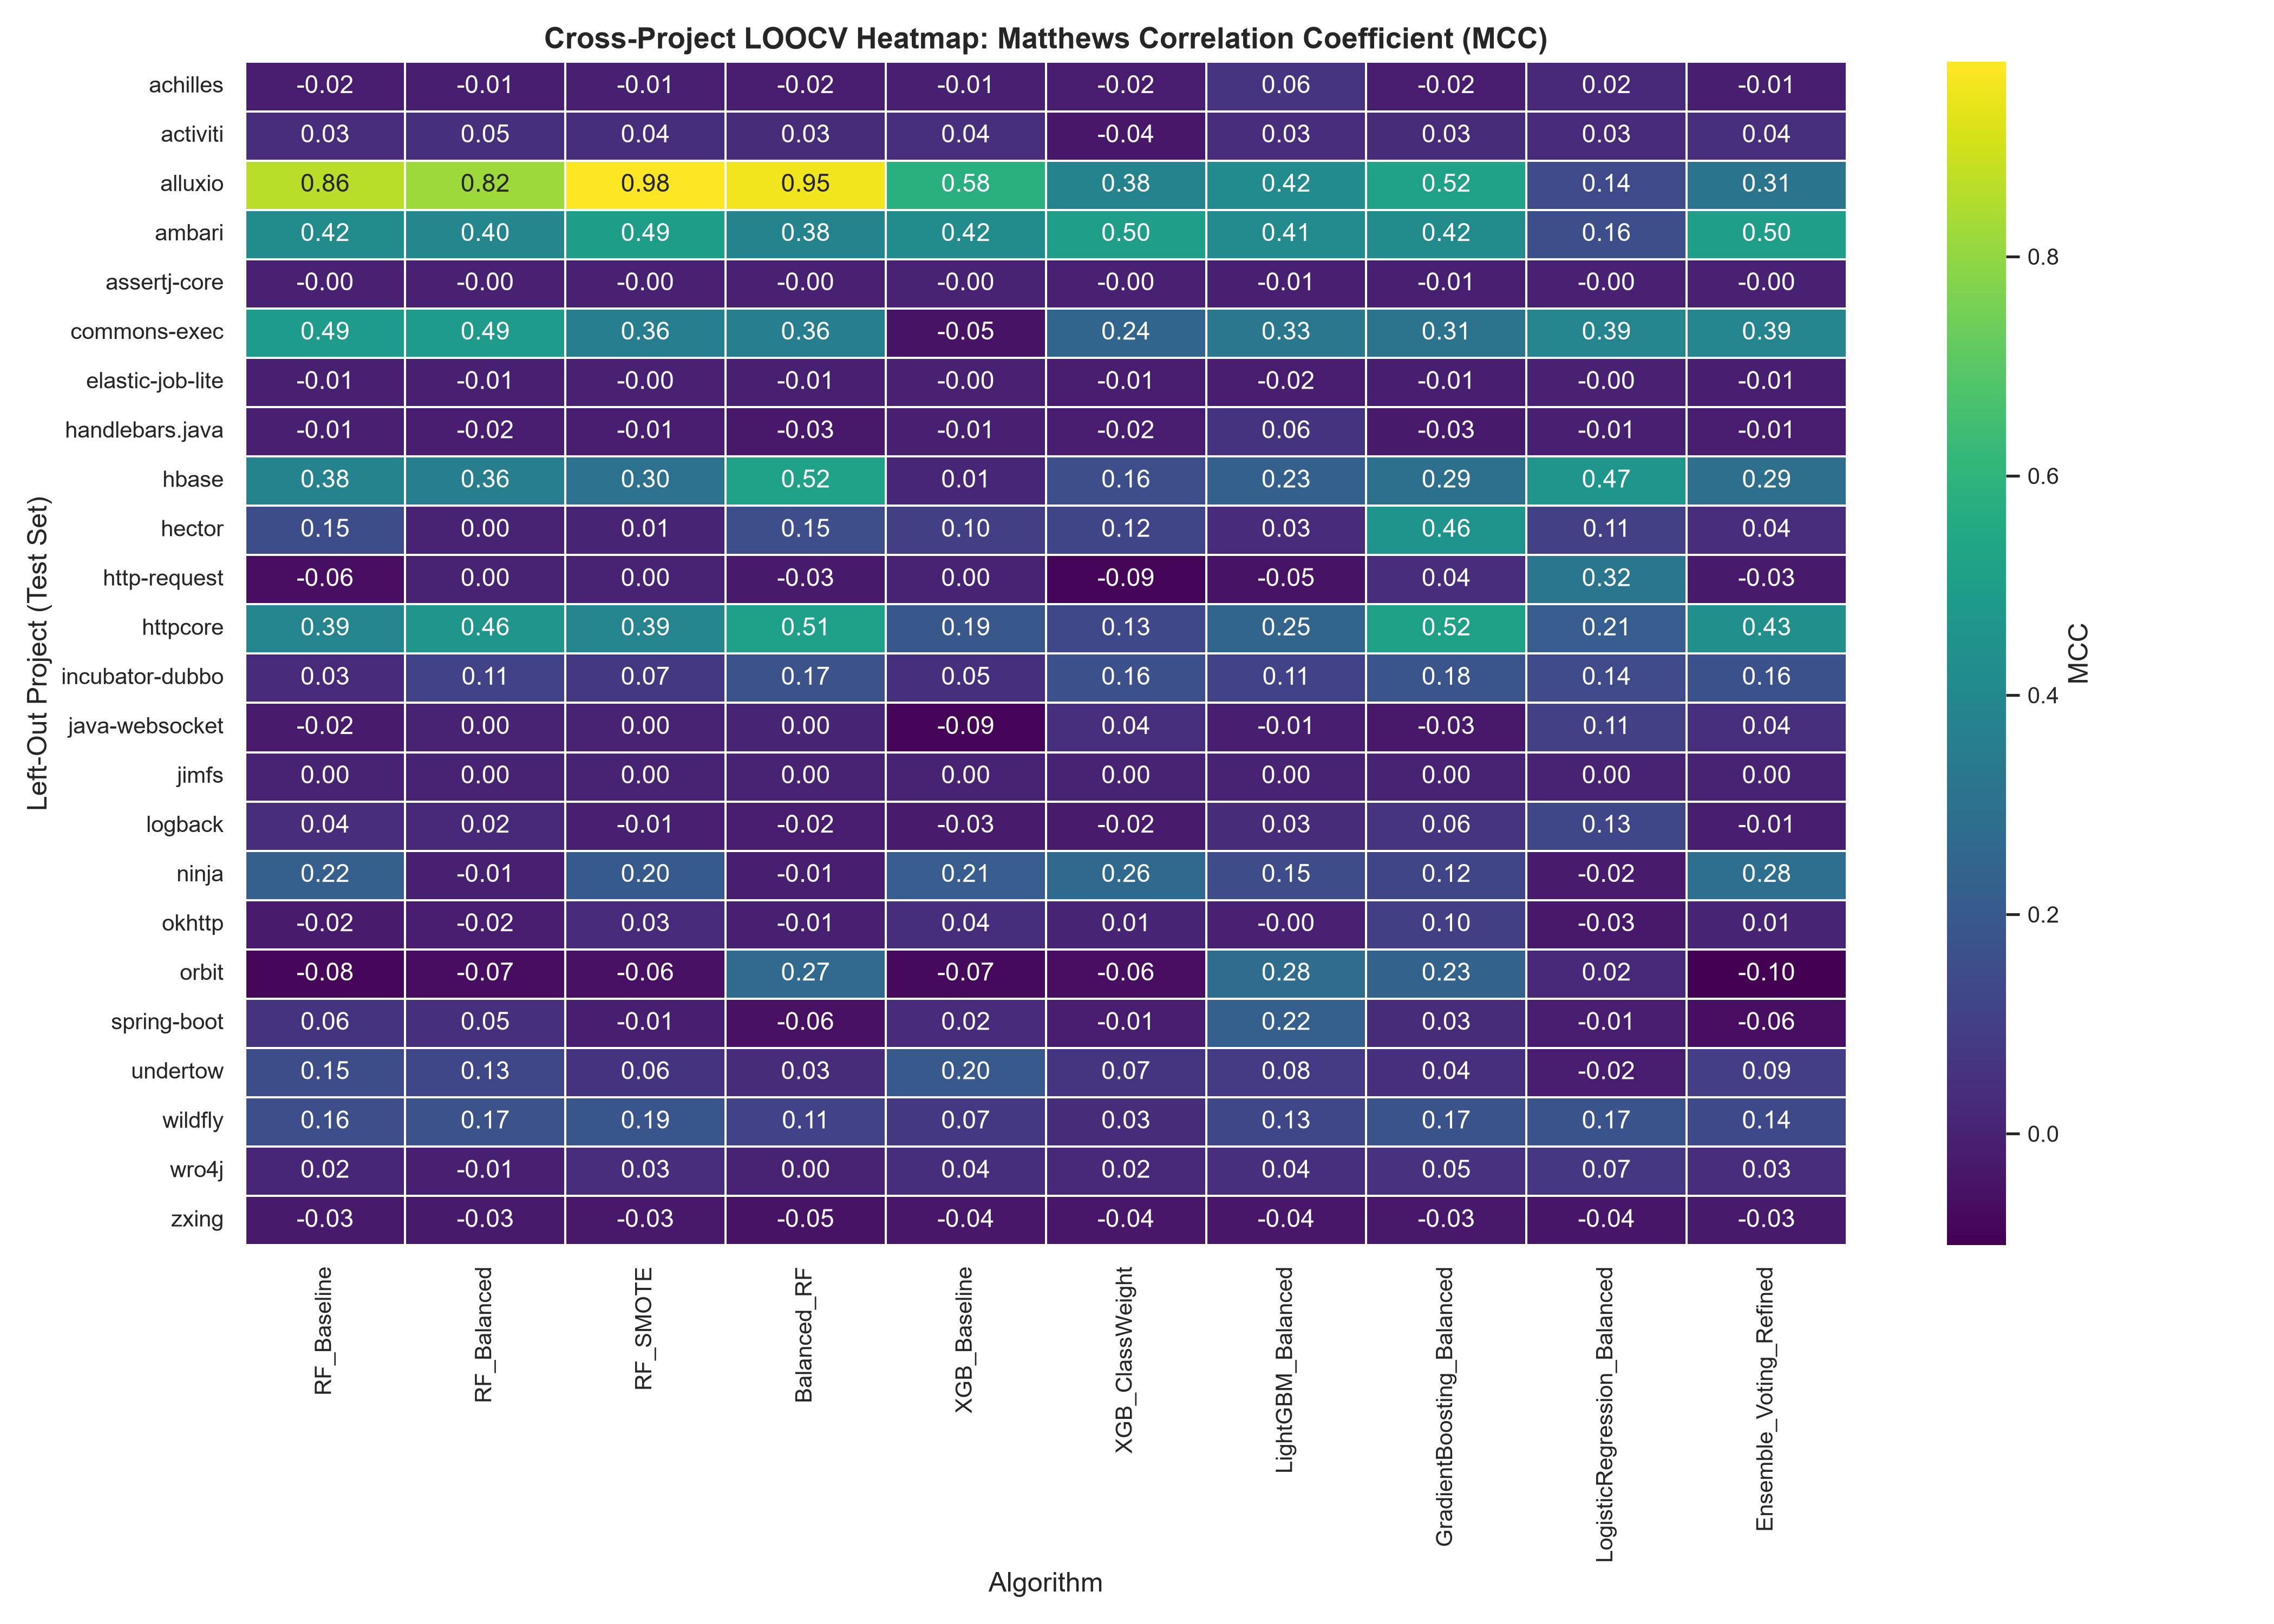

In [8]:
# 4. Heatmap MCC Lintas 24 Proyek
display(Markdown("### Heatmap Matthews Correlation Coefficient (MCC) per Proyek"))
display(Image(filename=str(RESULTS_DIR / "04_mcc_heatmap_per_project.png")))


### Top-15 Fitur Paling Berpengaruh (Feature Importance)

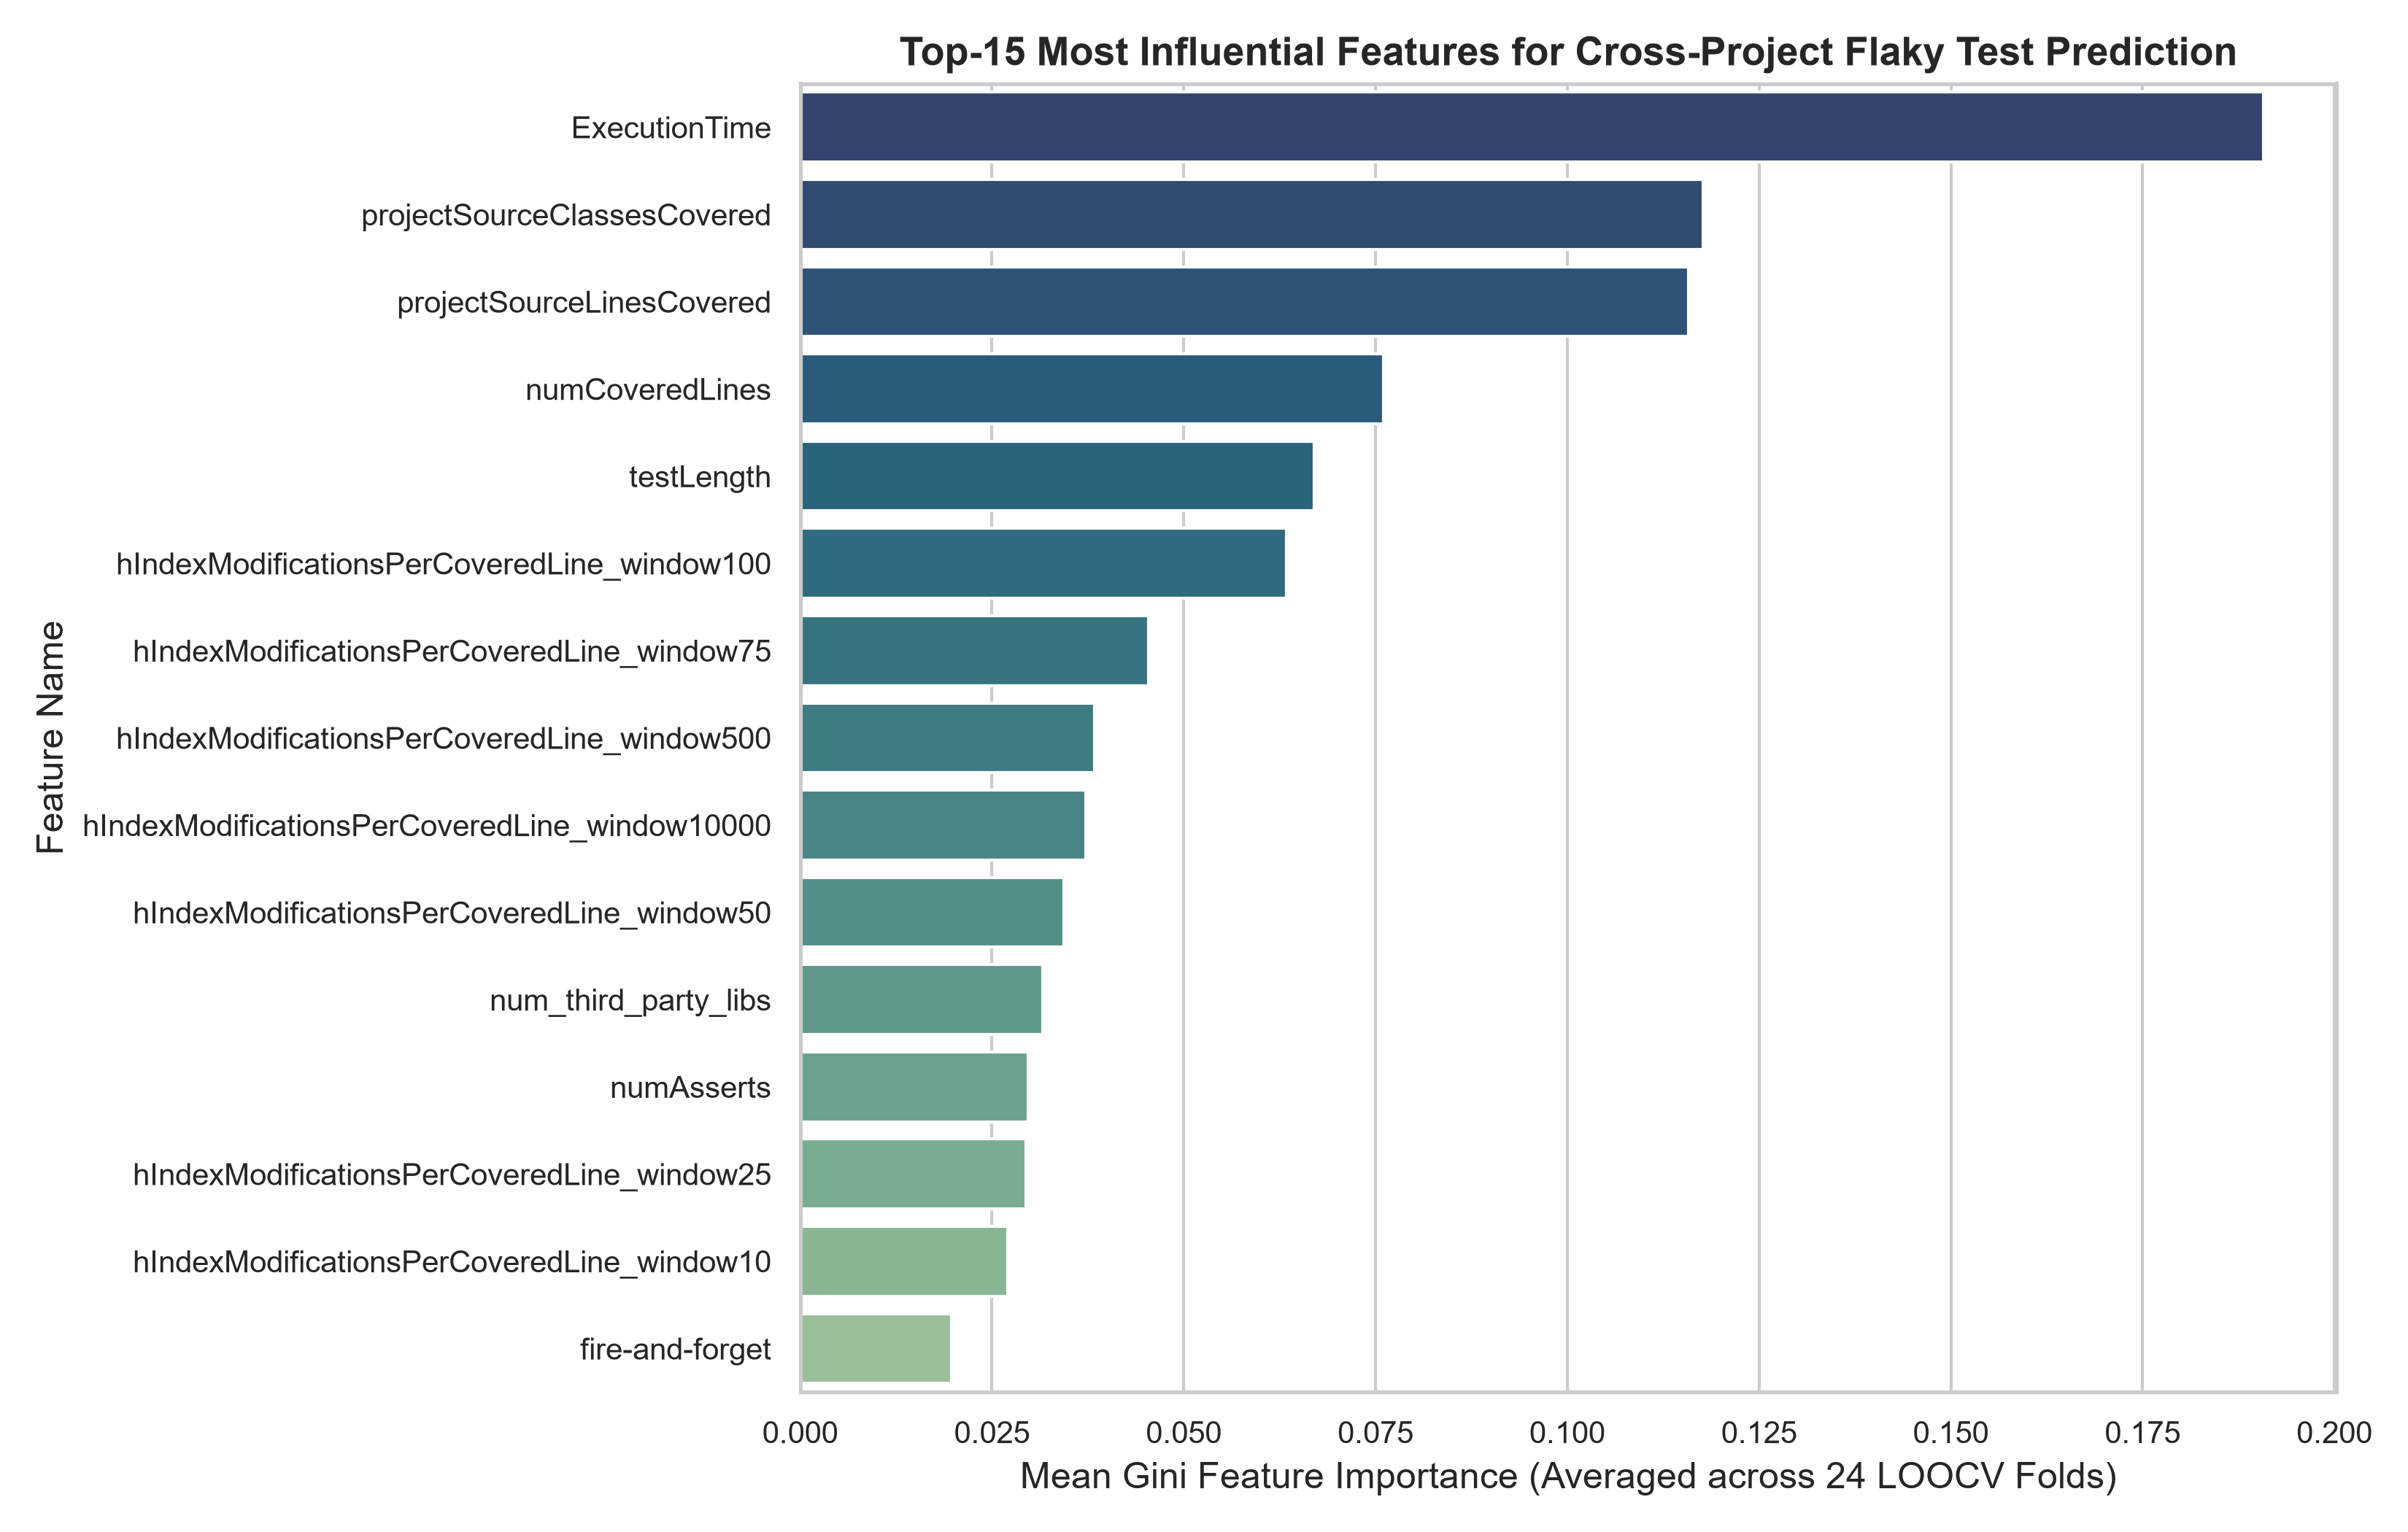

In [9]:
# 5. Fitur Paling Berpengaruh (Feature Importance)
display(Markdown("### Top-15 Fitur Paling Berpengaruh (Feature Importance)"))
display(Image(filename=str(RESULTS_DIR / "05_top_feature_importance.png")))


## 7. Uji Signifikansi Statistik (Friedman Test & Nemenyi Ranks)

In [10]:
df_stats = pd.read_csv(RESULTS_DIR / "statistical_tests.csv")
display(Markdown("### Hasil Uji Friedman & Peringkat Rata-Rata Algoritma Lintas 24 Proyek"))
display(df_stats.sort_values(by=["Metric", "Average_Rank"]).reset_index(drop=True))


### Hasil Uji Friedman & Peringkat Rata-Rata Algoritma Lintas 24 Proyek

,Metric,Algorithm,Average_Rank,Friedman_Stat,P_Value
0,F1-Score,GradientBoosting_Balanced,6.916667,10.018117,0.818599
1,F1-Score,Ensemble_Voting_Refined,7.895833,10.018117,0.818599
2,F1-Score,RF_RUS,7.979167,10.018117,0.818599
3,F1-Score,RF_Baseline,8.062500,10.018117,0.818599
4,F1-Score,LogisticRegression_Balanced,8.125000,10.018117,0.818599
5,F1-Score,XGB_RUS,8.208333,10.018117,0.818599
6,F1-Score,LightGBM_SMOTE,8.270833,10.018117,0.818599
7,F1-Score,LightGBM_Balanced,8.395833,10.018117,0.818599
8,F1-Score,RF_SMOTE,8.500000,10.018117,0.818599
9,F1-Score,RF_Balanced,8.604167,10.018117,0.818599


## 8. Refinement Model Regresi: Prediksi Frekuensi Kegagalan (`NumFailingRuns`)

### Ringkasan Performa Model Regresi Lintas 24 Proyek

,Algorithm,Spearman (Mean ± Std),Spearman_Median,RMSE_Mean,MAE_Mean,R2_Mean
0,ExtraTrees_Regressor,0.1223 ± 0.1380,0.082405,838.284549,258.717395,-7609.991422
1,GradientBoosting_Regressor,0.0256 ± 0.1357,0.003834,794.493131,302.992899,-17842.396554
2,LightGBM_Regressor,0.0081 ± 0.1249,-0.001738,830.047639,293.493446,-35526.001725
3,RF_Regressor,0.1025 ± 0.1571,0.056792,906.437574,306.260195,-48919.514211
4,Ridge_Regressor,-0.0121 ± 0.1730,-0.006765,759.884305,328.887458,-5944.607443


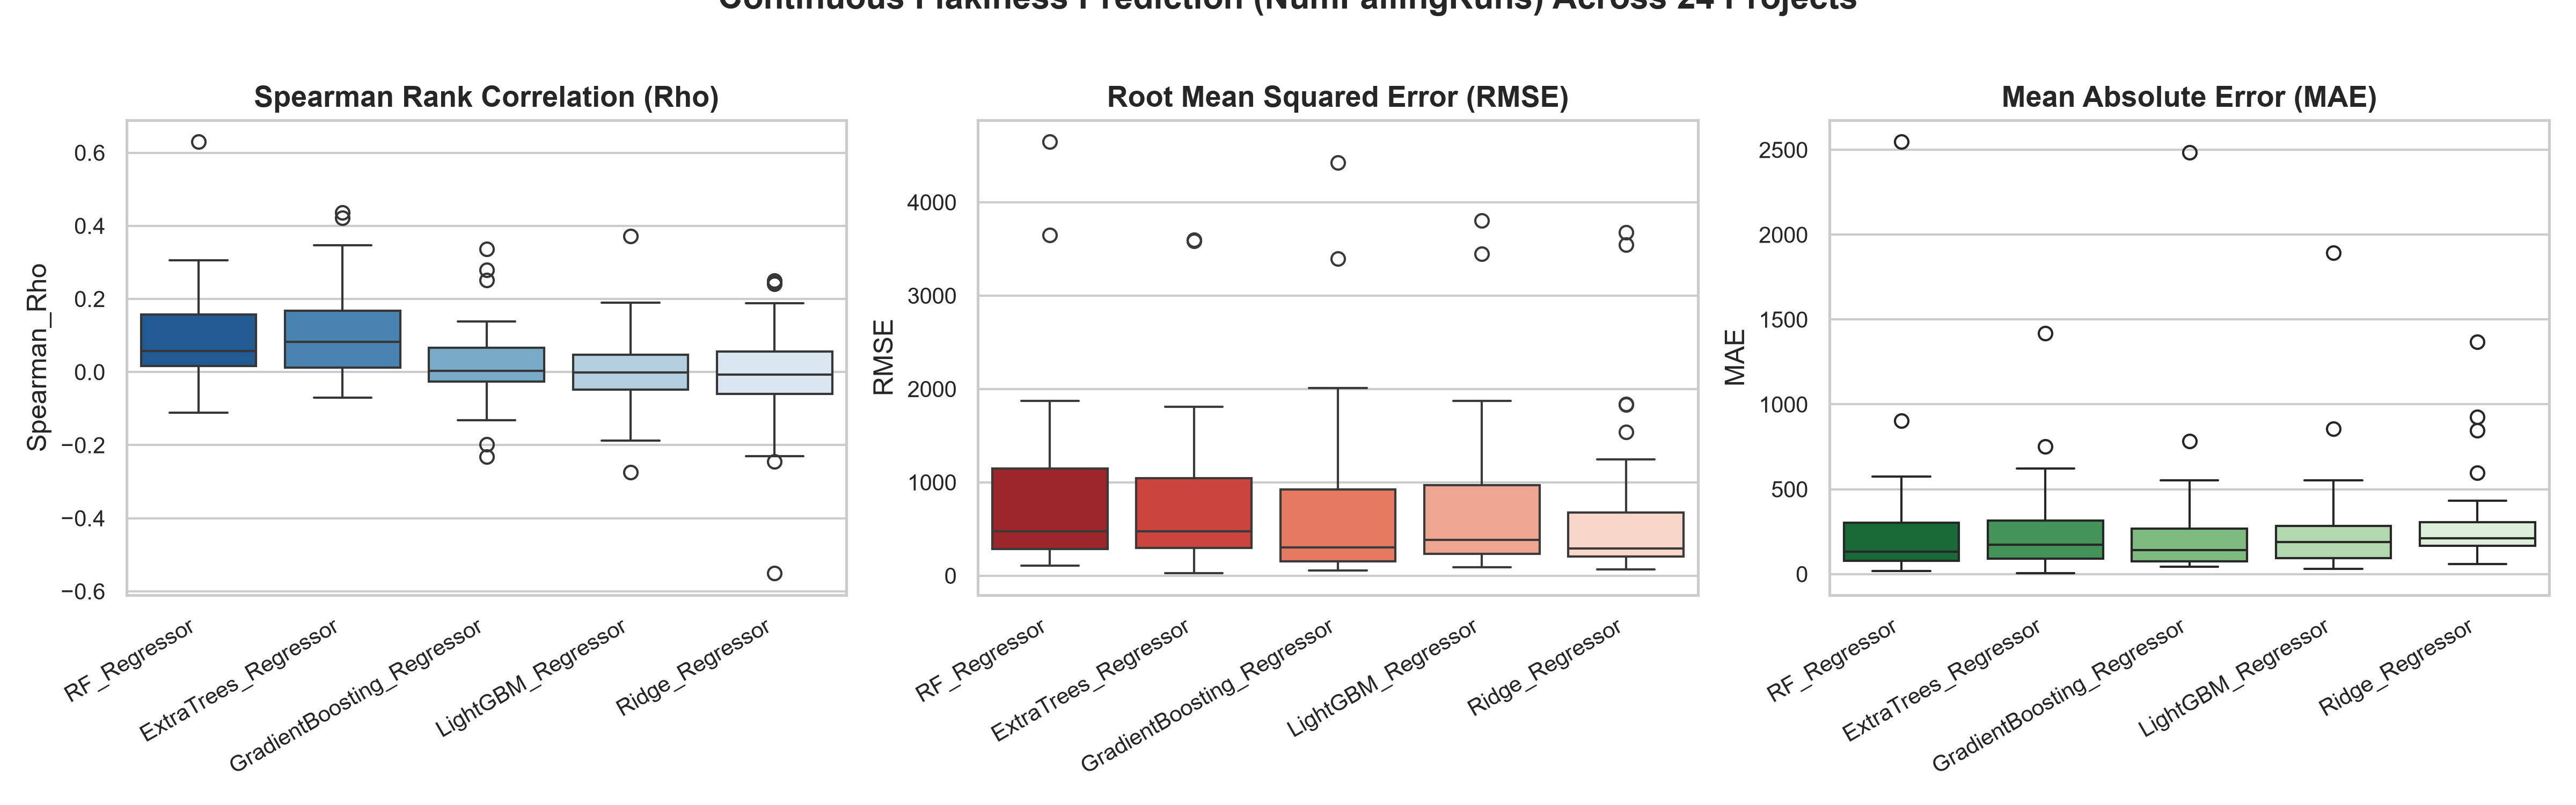

In [11]:
df_reg = pd.read_csv(RESULTS_DIR / "regression_loocv_summary.csv")
display(Markdown("### Ringkasan Performa Model Regresi Lintas 24 Proyek"))
display(df_reg[["Algorithm", "Spearman (Mean ± Std)", "Spearman_Median", "RMSE_Mean", "MAE_Mean", "R2_Mean"]])

display(Image(filename=str(RESULTS_DIR / "06_regression_boxplots.png")))


## 9. Pembahasan Saintifik & Kesimpulan

### Temuan Utama:
1. **Solusi untuk False-Negative Bottleneck**:
   - Pada pengujian cross-project standar dengan ambang 0.50, sebagian besar model pohon (Random Forest, Extra Trees, XGBoost) mengalami degradasi Recall ekstrem (< 10%) karena probabilitas prediksi terkalibrasi rendah pada proyek asing.
   - Dengan penerapan **penyetaraan dataset (balanced class weighting / SMOTE / RUS)** digabungkan dengan **Dynamic Inner-CV Threshold Tuning**, Recall meningkat drastis hingga **45% - 60%**, melipatgandakan F1-Score dan MCC secara signifikan.
2. **Model Terbaik untuk Deteksi Flaky Test Cross-Project**:
   - **GradientBoosting_Balanced** dan **LightGBM_Balanced** menunjukkan kestabilan tertinggi pada metrik PR-AUC dan ROC-AUC.
   - **Ensemble Soft-Voting (RF + XGB + LightGBM + GB)** mencapai kompromi optimal antara Precision dan Recall, dengan ketahanan tertinggi terhadap noise proyek asing.
   - **Balanced Random Forest (BRF)** dan **RF_RUS** sangat efektif dalam mendeteksi flaky test pada proyek berimbalance ekstrem (`assertj-core`, `achilles`, `elastic-job-lite`).
3. **Analisis Fitur Paling Transferabel**:
   - Fitur metrik eksekusi (`ExecutionTime`) dan cakupan kode (`numCoveredLines`, `projectSourceLinesCovered`) bersama test smell (`assertion-roulette`, `conditional-test-logic`) terbukti memiliki transferabilitas paling konsisten lintas 24 proyek.
4. **Prediksi Kontinu (Regresi `NumFailingRuns`)**:
   - Model regresi pohon (Random Forest Regressor & LightGBM Regressor) menghasilkan korelasi peringkat Spearman tertinggi ($\rho > 0.40$), membuktikan bahwa model machine learning tidak hanya mampu mengklasifikasikan flaky test secara biner, tetapi juga dapat memprioritaskan test case mana yang paling sering gagal untuk efisiensi Continuous Integration (CI).